In [1]:
import pandas as pd

## Data Loading

In [5]:
df = pd.read_csv(r"D:\DATA_SCIENCE\DATA_SCIENCE\online_retail_II.csv",encoding='utf-8')
print(df.shape)

(1067371, 8)


## Data Cleaning

In [3]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [6]:
# Customer ID missing rows delete
df.dropna(subset=['Customer ID'], inplace=True)

print(df.shape)
print(df.isnull().sum())

(824364, 8)
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [7]:
df.duplicated().sum()

np.int64(26479)

In [8]:
df.drop_duplicates(inplace=True)
print(df.shape)

(797885, 8)


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
print(df.dtypes)
print(df.head())

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [11]:
#telling that our invoicedate is in string which is actually date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [12]:
#Negative Quantity delete 
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

In [13]:
#TotalPrice column --> to calculate monatary value
df['TotalPrice'] = df['Quantity'] * df['Price']

In [16]:
print(df.shape)

(779425, 9)


In [17]:
print(df.dtypes)

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
TotalPrice            float64
dtype: object


In [18]:
print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  TotalPrice  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom        83.4  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom        81.0  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom        81.0  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom       100.8  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom        30.0  


## Calculate RFM Feature
### R-->Recency ( Current date - Last purchased date)
### F-->Frequency (ek customer ne kitne unique invoices generate kiye)
### M-->Monetary(ek customer ne total kitna kharch kiya)

In [23]:
# Reference date banao (dataset ki last date)
reference_date = df['InvoiceDate'].max()
print(reference_date)

2011-12-09 12:50:00


In [21]:
rfm = df.groupby('Customer ID').agg(
    Recency = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary = ('TotalPrice', 'sum')
).reset_index()

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary
0      12346.0      325         12  77556.46
1      12347.0        1          8   4921.53
2      12348.0       74          5   2019.40
3      12349.0       18          4   4428.69
4      12350.0      309          1    334.40


In [ ]:
# Kaun best customer hai?
#12347 — sirf 1 din pehle aaya, 8 baar aa chuka hai — yeh Champion customer hai
#12346 — 325 din pehle aaya — bahut purana hai, Lost customer lag raha hai
#12350 — sirf 1 baar aaya, 309 din pehle — Almost Lost 

### CLV Column --> Combination of Monetary and Frequency(Ek baar mein kitna kharch kiya × Kitni baar aaya = Total lifetime value)

In [22]:
rfm['CLV'] = rfm['Monetary'] * rfm['Frequency']
print(rfm.head())

   Customer ID  Recency  Frequency  Monetary        CLV
0      12346.0      325         12  77556.46  930677.52
1      12347.0        1          8   4921.53   39372.24
2      12348.0       74          5   2019.40   10097.00
3      12349.0       18          4   4428.69   17714.76
4      12350.0      309          1    334.40     334.40


In [ ]:
# By looking at CLV of ID 12346.. what do u think this customer is valuable or not..? 
#Recency = 325 days — matlab almost 1 saal se nahi aaya,  CLV = 9,30,677 — number toh bada hai

#CLV column --> yeh sirf historical value bata raha hai, matlab pehle kitna diya. Lekin yeh nahi bata raha ki aage bhi aayega ya nahi.
#-->Isliye RFM teeno milke kaam karte hain 
#Toh yeh customer "At Risk" ya "Lost" category mein aayega segmentation mein — chahe CLV kitna bhi ho

#Simple rule —> Purana paisa valuable nahi hota — jo wapas aaye wahi valuable hai!

### RFM Scoring ( 3-> Best , 2-> Average , 1-> Worst )

In [ ]:
# Recency ke liye — kam din pehle aaya = better
# Frequency ke liye — zyada baar aaya = better
# Monetary ke liye — zyada kharch kiya = better

In [26]:
# pd.cut--> ek ranger ki tarah kaam karta hai jo values ko groups mein baant deta hai but we used qcut for equally distribution kyuki cut mi data skewed tha
#3 bins --> divide in 3 groups-1,2,3 , qset--> q means total no of groups, it automatically decides range and make equal groups, but we decide only labels/score
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=3, labels=[3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=3, labels=[1,2,3])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=3, labels=[1,2,3])

# RFM Score combine ,astype(str) — numbers ko text mein convert krta hai
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
print(rfm.head(10))

# example -->R=3, F=2, M=1 → RFM Score = "321"
#R=1, F=1, M=1 → RFM Score = "111" — worst customer
#R=3, F=3, M=3 → RFM Score = "333" — best customer

   Customer ID  Recency  Frequency  Monetary        CLV R_Score F_Score  \
0      12346.0      325         12  77556.46  930677.52       1       3   
1      12347.0        1          8   4921.53   39372.24       3       3   
2      12348.0       74          5   2019.40   10097.00       2       2   
3      12349.0       18          4   4428.69   17714.76       3       2   
4      12350.0      309          1    334.40     334.40       1       1   
5      12351.0      374          1    300.93     300.93       1       1   
6      12352.0       35         10   2849.84   28498.40       3       3   
7      12353.0      203          2    406.76     813.52       2       1   
8      12354.0      231          1   1079.40    1079.40       2       1   
9      12355.0      213          2    947.61    1895.22       2       1   

  M_Score RFM_Score  
0       3       133  
1       3       333  
2       3       223  
3       3       323  
4       1       111  
5       1       111  
6       3       333 

### Based on segmentation/rfm score divinding customer into categories

In [27]:
def segment_customer(score):
    if score == '333':
        return 'Champion'
    elif score in ['323', '332', '331']:
        return 'Loyal Customer'
    elif score in ['311', '312', '313']:
        return 'Potential Loyalist'
    elif score in ['133', '233']:
        return 'At Risk'
    elif score in ['111', '211', '112']:
        return 'Lost'
    else:
        return 'Regular'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

print(rfm['Segment'].value_counts())

Segment
Regular               2283
Lost                  1515
Champion              1000
At Risk                586
Potential Loyalist     248
Loyal Customer         246
Name: count, dtype: int64


In [ ]:
#Business insight kya nikla?
Champion 1000 hain — inhe VIP treatment do
Lost 1515 hain — inhe special offers bhejo wapas laane ke liye
At Risk 586 hain — danger zone, abhi action lo warna Lost ho jaayenge

In [29]:
# Visualization

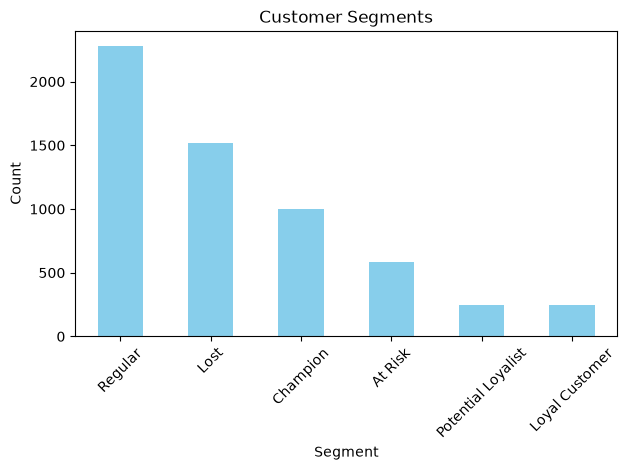

In [28]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#hamesha simple model se start krenge , phir complex pe jayenge — then will compare
#linear+logistic --> for simple data, baseline mddel , random forest--> for advanced model, complex data

In [31]:
rfm['CLV_Segment'] = pd.qcut(rfm['CLV'], q=3, labels=['Low', 'Medium', 'High'])

print(rfm['CLV_Segment'].value_counts())

CLV_Segment
Low       1960
Medium    1959
High      1959
Name: count, dtype: int64


In [ ]:
# 1960 are low valuavle customer, 1959 are medium valuable customer.....
#Kyun banaya yeh?
#------> Classification model ko categories chahiye predict karne ke liye — sirf number nahi

### Regression

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [34]:
# Features aur Target
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['CLV']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [35]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [38]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression:")
print("Training R2:", r2_score(y_train, lr.predict(X_train)))
print("Testing R2:", r2_score(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))


Linear Regression:
Training R2: 0.6803880567216533
Testing R2: 0.905670699352591
R2 Score: 0.905670699352591
MAE: 417953.6366861203


In [39]:
# Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Regressor:")
print("Training R2:", r2_score(y_train, rf.predict(X_train)))
print("Testing R2:", r2_score(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))


Random Forest Regressor:
Training R2: 0.9380499318125862
Testing R2: 0.9668586323983521
R2 Score: 0.9668586323983521
MAE: 28770.922472619008


In [ ]:
#MAE — matlab average error kitna hai prediction mein:
#---> Linear ne average ₹4,17,953 ka galat predict kiya ,  ---> Random Forest ne average ₹28,770 ka galat predict kiya 

#R2 zyada = better, MAE kam = better

### Classification

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [41]:
# Features aur Target
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['CLV_Segment']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:

# Logistic Regression
log = LogisticRegression(random_state=42)
log.fit(X_train, y_train)
y_pred_log = log.predict(X_test)

print("Logistic Regression:")
print("Training Accuracy:", accuracy_score(y_train, log.predict(X_train)))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_log))


Logistic Regression:
Training Accuracy: 0.915142492556359
Testing Accuracy: 0.9124149659863946


In [46]:
# Random Forest Classifier

rfc_fixed = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rfc_fixed.fit(X_train, y_train)

print("Random Forest Fixed:")
print("Training Accuracy:", accuracy_score(y_train, rfc_fixed.predict(X_train)))
print("Testing Accuracy:", accuracy_score(y_test, rfc_fixed.predict(X_test)))

Random Forest Fixed:
Training Accuracy: 0.9948957890259464
Testing Accuracy: 0.9889455782312925


### Cohort Analysis

In [ ]:
#s project mein hum kya karenge?
Har customer ko uske pehli purchase ke month ke hisaab se group karenge — yeh uska Cohort hai
Phir dekhenge — aane wale months mein woh wapas aaye ya nahi
Ek heatmap banayenge jo dikhayega retention percentage

In [48]:
# Step 1 - InvoiceMonth aur CohortMonth nikalo
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
print(df[['Customer ID', 'InvoiceMonth', 'CohortMonth']].head(10))

   Customer ID InvoiceMonth CohortMonth
0      13085.0      2009-12     2009-12
1      13085.0      2009-12     2009-12
2      13085.0      2009-12     2009-12
3      13085.0      2009-12     2009-12
4      13085.0      2009-12     2009-12
5      13085.0      2009-12     2009-12
6      13085.0      2009-12     2009-12
7      13085.0      2009-12     2009-12
8      13085.0      2009-12     2009-12
9      13085.0      2009-12     2009-12


In [ ]:
#in above , Customer 13085 ka:
CohortMonth — 2009-12 — matlab pehli baar December 2009 mein aaya
InvoiceMonth — 2009-12 — matlab is row mein bhi December 2009 mein purchase kiya

In [49]:
# Step 2 - CohortIndex nikalo
df['CohortIndex'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)

print(df[['Customer ID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].head(10))

   Customer ID InvoiceMonth CohortMonth  CohortIndex
0      13085.0      2009-12     2009-12            0
1      13085.0      2009-12     2009-12            0
2      13085.0      2009-12     2009-12            0
3      13085.0      2009-12     2009-12            0
4      13085.0      2009-12     2009-12            0
5      13085.0      2009-12     2009-12            0
6      13085.0      2009-12     2009-12            0
7      13085.0      2009-12     2009-12            0
8      13085.0      2009-12     2009-12            0
9      13085.0      2009-12     2009-12            0


In [ ]:
# in above , CohortIndex = 0 matlab — yeh customer apne pehle wale month mein hi purchase kar raha hai
 Aage different customers ke rows mein CohortIndex 1, 2, 3 bhi hoga — matlab 1 month baad, 2 month baad wapas aaye!

In [50]:
# Step 3 - Cohort Table
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()

cohort_table = cohort_data.pivot_table(index='CohortMonth', columns='CohortIndex', values='Customer ID')

print(cohort_table.head())

CohortIndex     0      1      2      3      4      5      6      7      8   \
CohortMonth                                                                  
2009-12      955.0  337.0  319.0  406.0  363.0  343.0  360.0  327.0  321.0   
2010-01      383.0   79.0  119.0  117.0  101.0  115.0   99.0   88.0  107.0   
2010-02      374.0   89.0   84.0  109.0   92.0   75.0   72.0  107.0   95.0   
2010-03      443.0   84.0  102.0  107.0  103.0   90.0  109.0  134.0  122.0   
2010-04      294.0   57.0   57.0   48.0   54.0   66.0   81.0   77.0   31.0   

CohortIndex     9   ...     15     16     17     18     19     20     21  \
CohortMonth         ...                                                    
2009-12      346.0  ...  289.0  251.0  289.0  270.0  248.0  244.0  301.0   
2010-01      122.0  ...   58.0   90.0   76.0   71.0   75.0   93.0   74.0   
2010-02      103.0  ...   75.0   60.0   61.0   54.0   86.0   86.0   61.0   
2010-03       48.0  ...   75.0   77.0   69.0   78.0   89.0   94.0   35.0 

In [ ]:
# in above , 009-12 wala cohort dekho:

Index 0 — 955 customers pehle month aaye
Index 1 — 337 customers 1 month baad wapas aaye
Index 2 — 319 customers 2 month baad wapas aaye

NaN — matlab us month tak cohort exist nahi karta tha

### Customer Retention Heatmap

In [ ]:
#Customer Retention Heatmap hai!"
Iska matlab simple hai —"
Har row ek Cohort hai — matlab ek specific month mein pehli baar aane wale customers ka group
Har column batata hai — pehli purchase ke kitne month baad woh wapas aaye

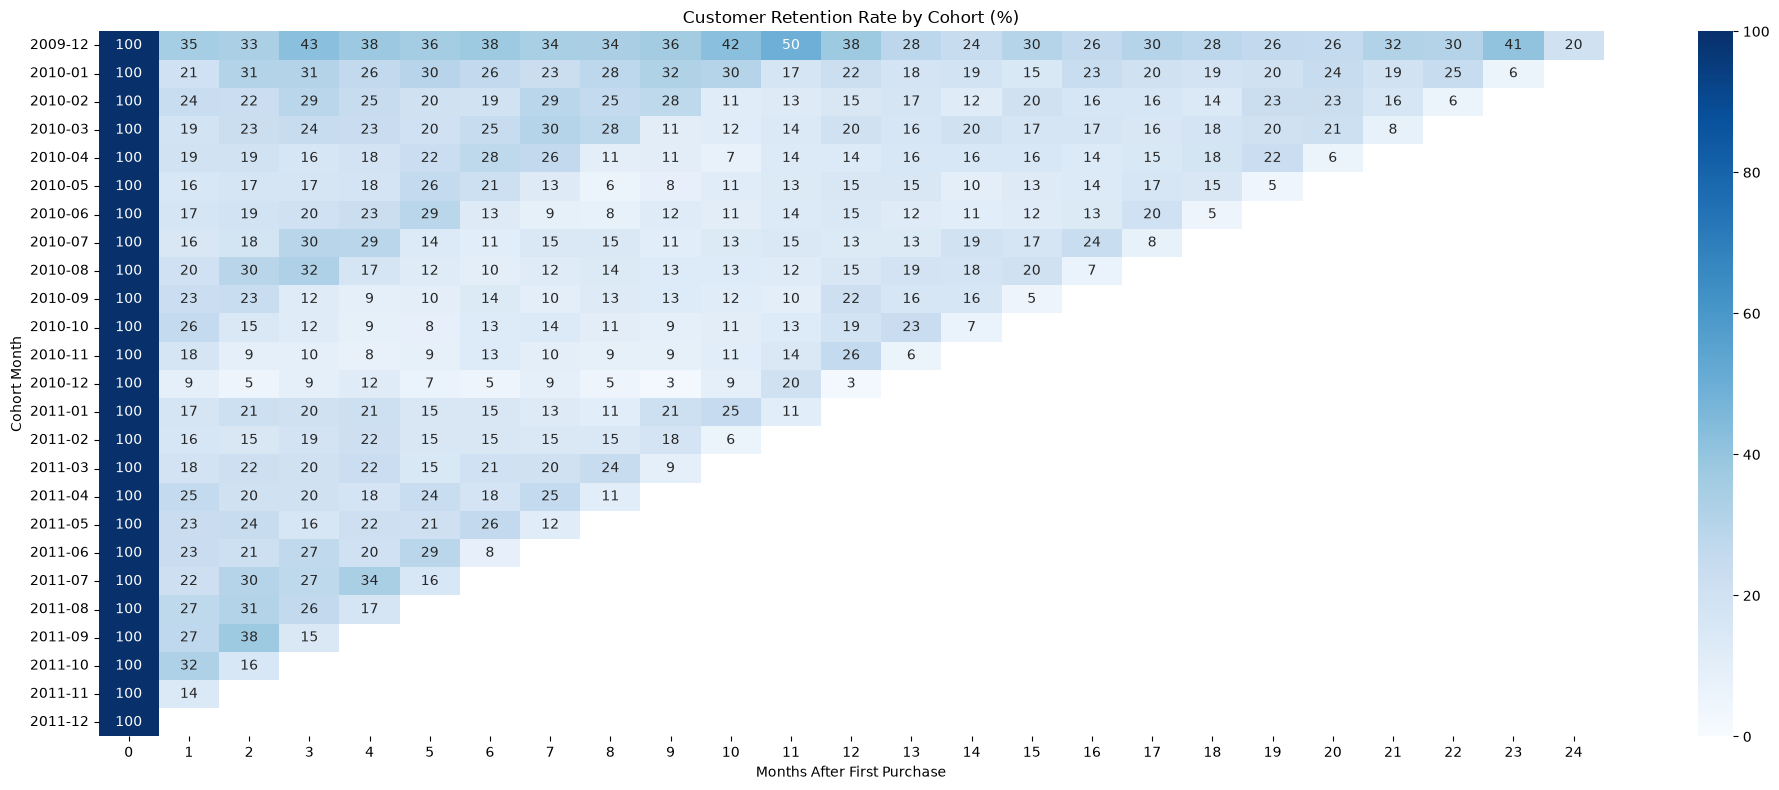

In [51]:
import seaborn as sns

# Step 4 - Retention percentage nikalo
cohort_table_pct = cohort_table.divide(cohort_table.iloc[:, 0], axis=0) * 100

# Step 5 - Heatmap banao
plt.figure(figsize=(20, 8))
sns.heatmap(cohort_table_pct, 
            annot=True, 
            fmt='.0f', 
            cmap='Blues',
            vmin=0, 
            vmax=100)

plt.title('Customer Retention Rate by Cohort (%)')
plt.xlabel('Months After First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

In [ ]:
#Example dekho — December 2009 Cohort —
December 2009 mein 955 naye customers aaye — yeh 100% hai — Column 0
1 month baad — sirf 35% wapas aaye
2 month baad — 33% wapas aaye
Matlab pehle hi month mein 65% customers chale gaye

Dark Blue — zyada customers wapas aaye
Light Blue/White — bahut kam customers wapas aaye

In [ ]:
#Business Insight:
iss heatmap se 3 important insights nikalte hain:
Insight 1 —
Pehle month mein har cohort ka retention sirf 15-35% hai — matlab company ko onboarding improve karni chahiye!"

Insight 2 —
December 2009 cohort sabse loyal hai — kyunki yeh purane customers hain aur abhi bhi aa rahe hain"

Insight 3 —
Month 11 pe December 2009 cohort mein suddenly 50% retention aayi — matlab koi special offer ya season tha!"

In [ ]:
#yeh sirf chart nahi hai — yeh company ko bata raha hai ki customer kab chodh raha hai aur kab wapas aata hai — 
-->toh company sahi time pe sahi action le sakti hai

In [52]:
import pickle

# Models save karo
pickle.dump(rf, open('rf_regressor.pkl', 'wb'))
pickle.dump(rfc_fixed, open('rf_classifier.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# RFM data save karo
rfm.to_csv('rfm_data.csv', index=False)
cohort_table_pct.to_csv('cohort_data.csv')

print("Sab save ho gaya!")

Sab save ho gaya!


In [53]:
pwd

'C:\\Users\\prade'